# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Load dataset
df = pd.read_csv('/content/dataset.csv')

# Tampilkan 5 baris pertama
print('Shape dataset:', df.shape)
print('\n5 baris pertama:')
df.head()

Shape dataset: (4238, 16)

5 baris pertama:


,Gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,Heart_ stroke
0,Male,39,postgraduate,0,0.0,0.0,no,0,0,195.0,106.0,70.0,26.97,80.0,77.0,No
1,Female,46,primaryschool,0,0.0,0.0,no,0,0,250.0,121.0,81.0,28.73,95.0,76.0,No
2,Male,48,uneducated,1,20.0,0.0,no,0,0,245.0,127.5,80.0,25.34,75.0,70.0,No
3,Female,61,graduate,1,30.0,0.0,no,1,0,225.0,150.0,95.0,28.58,65.0,103.0,yes
4,Female,46,graduate,1,23.0,0.0,no,0,0,285.0,130.0,84.0,23.10,85.0,85.0,No


In [5]:
print(df.columns.tolist())

['Gender', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'Heart_ stroke']


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           4238 non-null   object 
 1   age              4238 non-null   int64  
 2   education        4133 non-null   object 
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   object 
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  Heart_ stroke    4238 non-null   object 
dtypes: float64(8), int64(4), object(4)
memo

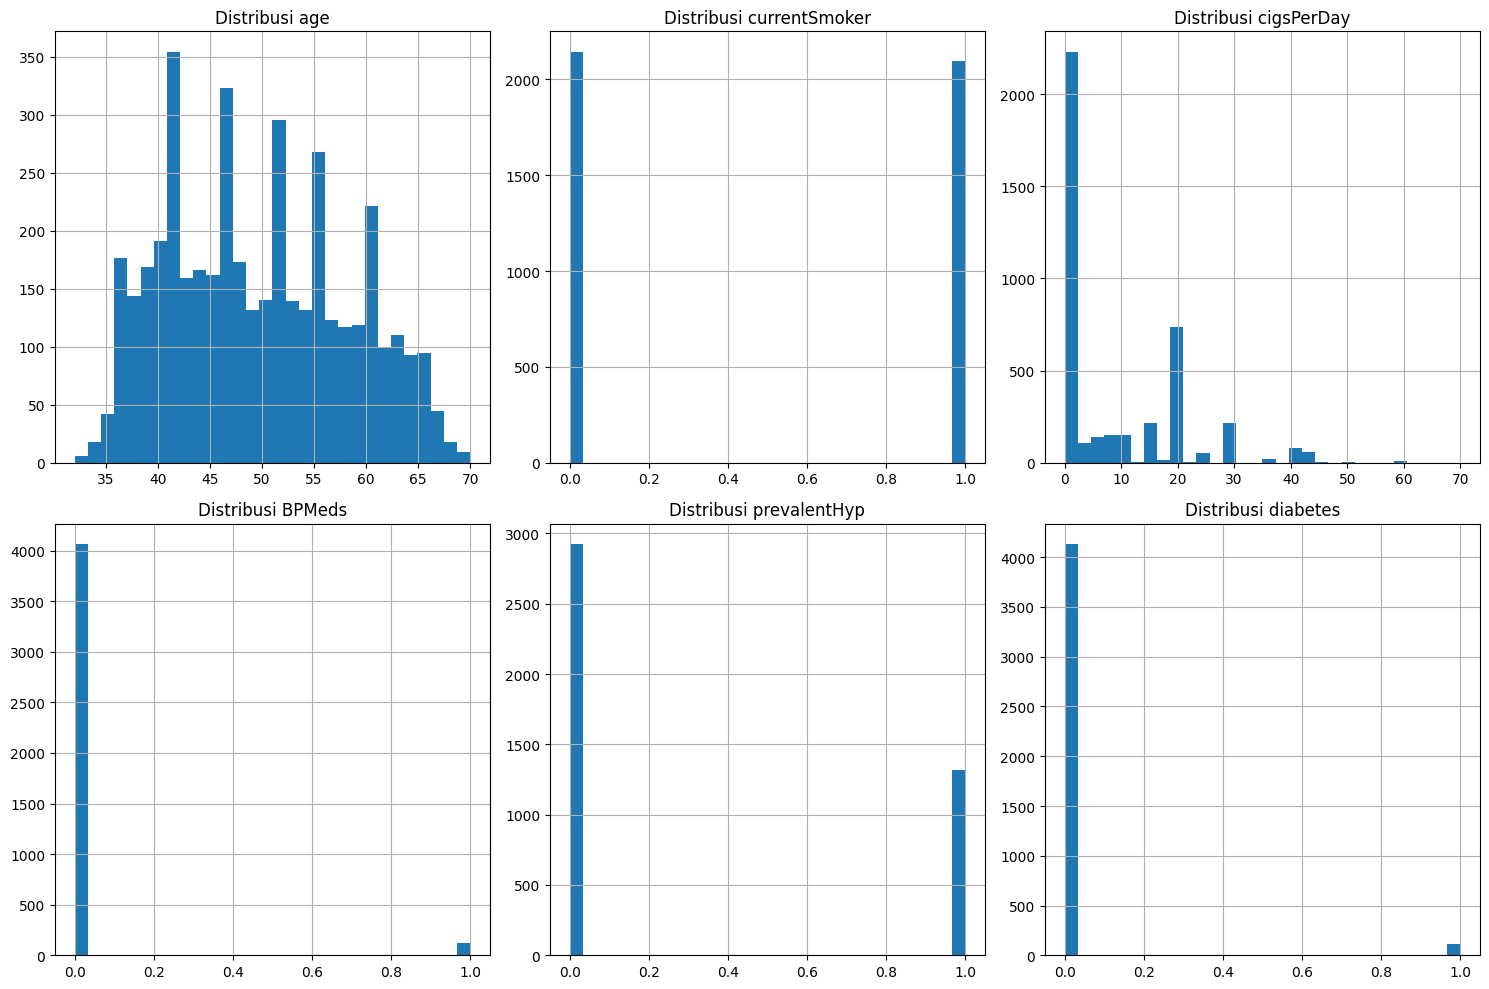

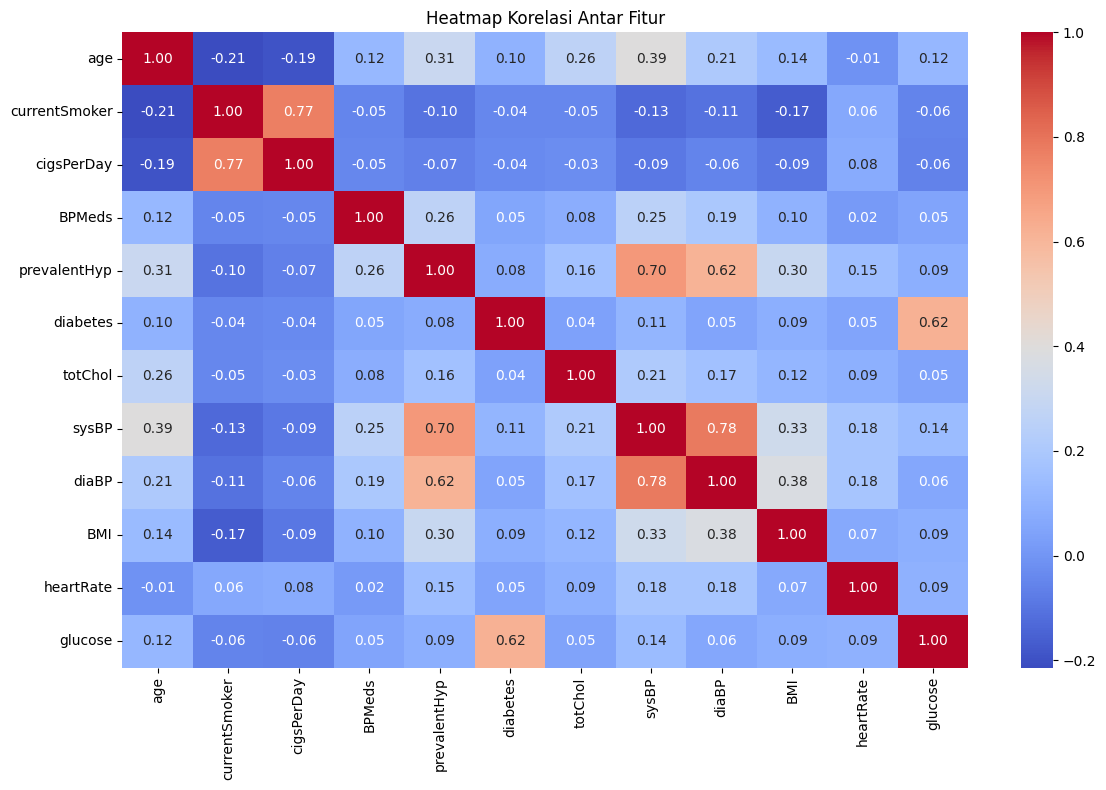

In [6]:
# ============================================================
# BAGIAN 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# 3.1 Informasi dasar dataset
print('=== INFO DATASET ===')
df.info()

# 3.2 Statistik deskriptif
print('\n=== STATISTIK DESKRIPTIF ===')
df.describe()

# 3.3 Cek nilai yang hilang (missing values)
print('\n=== MISSING VALUES ===')
print(df.isnull().sum())
print('\nPersentase missing values:')
print(df.isnull().sum() / len(df) * 100)

# 3.4 Cek duplikasi
print('\n=== DUPLIKASI ===')
print('Jumlah baris duplikat:', df.duplicated().sum())

# 3.5 Distribusi target (jika klasifikasi)
print('\n=== DISTRIBUSI TARGET ===')
print(df['Heart_ stroke'].value_counts())

# 3.6 Visualisasi distribusi fitur numerik
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for i, col in enumerate(numerical_cols[:6]):
    df[col].hist(ax=axes[i//3][i%3], bins=30)
    axes[i//3][i%3].set_title(f'Distribusi {col}')
plt.tight_layout()
plt.savefig('eda_distribusi.png')
plt.show()

# 3.7 Heatmap korelasi
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.savefig('eda_korelasi.png')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [7]:
# ============================================================
# BAGIAN 4: PREPROCESSING
# ============================================================

# 4.1 Pisahkan fitur dan target
X = df.drop('Heart_ stroke', axis=1)  # ganti 'target_column'
y = df['Heart_ stroke']

# 4.2 Handle Missing Values
# Untuk kolom numerik: isi dengan median
num_imputer = SimpleImputer(strategy='median')
numerical_cols = X.select_dtypes(include=[np.number]).columns
X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])

# Untuk kolom kategorik: isi dengan modus
cat_imputer = SimpleImputer(strategy='most_frequent')
categorical_cols = X.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

# 4.3 Encoding kolom kategorik
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

# 4.4 Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 4.5 Hapus duplikat (jika ada)
df_clean = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)
df_clean = df_clean.drop_duplicates()

# 4.6 Split data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print('Shape X_train:', X_train.shape)
print('Shape X_test:', X_test.shape)

# 4.7 Simpan dataset yang sudah diproses
df_clean.to_csv('/content/dataset_clean.csv', index=False)
print('Dataset berhasil disimpan!')


Shape X_train: (3390, 15)
Shape X_test: (848, 15)
Dataset berhasil disimpan!
